# Inverse design quickstart

This notebook will get users up and running with a very simple [inverse design optimization](https://www.flexcompute.com/tidy3d/inverse-design/) with `tidy3d`. Inverse design uses the **adjoint method** to compute gradients of a figure of merit with respect to design parameters using only 2 simulations, no matter how many design parameters are present. This gradient is then used to do high-dimensional gradient-based optimization of the system.

The setup we'll demonstrate here involves a point dipole source and a point field monitor on either side of a dielectric box. We use gradient-based optimization to maximize the intensity enhancement at the measurement spot with respect to the box size in all 3 dimensions.

<img src="img/Adjoint_Quickstart.png" width="300" alt="Schematic of the design problem.">

For more advanced examples and tutorial notebooks, check out

* [Tidy3D Autograd Tutorial](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/).

* [Topology Optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/).

* [Shape Optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd5BoundaryGradients/).

* [Grating Coupler Inverse Design](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd6GratingCoupler/).

To see all Tidy3D [examples](https://www.flexcompute.com/tidy3d/learning-center/example-library/) and [tutorials](https://www.flexcompute.com/tidy3d/learning-center/tidy3d-python/), as well as other learning materials, please visit our [Learning Center](https://www.flexcompute.com/tidy3d/learning-center/).


In [1]:
import autograd as ag
import autograd.numpy as anp
import matplotlib.pylab as plt
import tidy3d as td
from tidy3d.web import run

## Setup

First, we set up some basic parameters and "static" components of our simulation.

In [2]:
# wavelength and frequency
wavelength = 1.55
freq0 = td.C_0 / wavelength

# permittivity of box
eps_box = 2

# size of sim in x,y,z
L = 10 * wavelength

# spacing between source, monitor, and PML / box
buffer = 1.0 * wavelength

Create a [PointDipole](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PointDipole.html) source.

In [3]:
# create a dipole source on the left side of the simulation
source = td.PointDipole(
    center=(-L / 2 + buffer, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10.0),
    polarization="Ez",
)

Create a point [FieldMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html).

In [4]:
# create a monitor on the right side of the simulation to measure field intensity
monitor = td.FieldMonitor(
    center=(+L / 2 - buffer, 0, 0),
    size=(0.0, 0.0, 0.0),
    freqs=[freq0],
    name="point",
)

Create a function that takes the input parameter (size of the box) and returns a Tidy3D [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) objective with the source and monitor defined above.

To visualize the simulation setup, we create an initial simulation with a box of size 2.5 μm and visualize it.

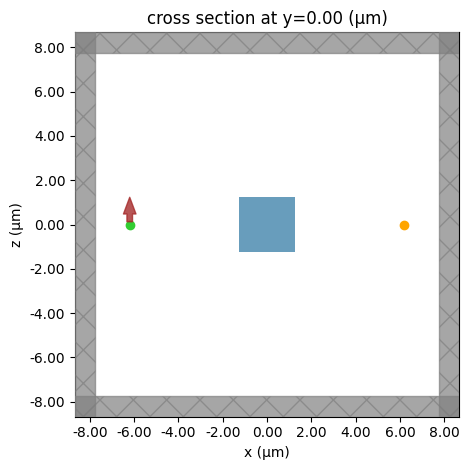

In [5]:
def make_sim(size_box: float) -> td.Simulation:
    """Create the simulation given a box size."""
    # create the box
    box = td.Structure(
        geometry=td.Box(center=(0, 0, 0), size=(size_box, size_box, size_box)),
        medium=td.Medium(permittivity=eps_box),
    )

    # create the simulation
    sim = td.Simulation(
        size=(L, L, L),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=20),
        structures=[box],
        sources=[source],
        monitors=[monitor],
        run_time=5e-13,
    )
    return sim


size_box = 2.5  # initial box size

# create a simulation and visualize the setup
sim_0 = make_sim(size_box)
sim_0.plot(y=0)
plt.show()

## Define Objective Function

The crucial step in inverse design is to define the objective function. Now we can construct our objective function, which is simply the intensity at the measurement point as a function of the box size.

In [6]:
def objective_fn(size_box: float) -> float:
    """Calculate the intensity at the monitor position given a box size."""

    # make the sim using the box size
    sim = make_sim(size_box)

    # run sim through tidy3d web API
    sim_data = run(sim, task_name="adjoint_quickstart", verbose=False)

    # evaluate the intensity at the measurement position
    intensity = anp.sum(sim_data.get_intensity(monitor.name).values)

    return intensity

To visualize the simulation setup, we create an initial simulation with a box of size 2.5 μm and visualize it.

## Optimization Loop

Next, we use `autograd` to construct a function that returns the gradient of our objective function and use this to run our gradient-based optimization in a for loop.

In [7]:
# use autograd to get a function that returns the objective function and its gradient
val_and_grad_fn = ag.value_and_grad(objective_fn)

In [8]:
# store history
objective_history = []  # list to store the history of the objective function
param_history = [size_box]  # list to store the history of the box size

# we will run the optimization for 9 iterations
for i in range(9):
    print(f"step = {i + 1}\n\tsize_box = {size_box:.2f}", end="")

    # compute gradient and current objective function value
    value, gradient = val_and_grad_fn(size_box)
    print(f"\n\tintensity = {value:.2e}")

    # update the parameter with the gradient and a learning rate of 2e-4
    size_box = size_box + gradient * 2e-4

    # save history
    objective_history.append(value)
    param_history.append(size_box)

# add the objective function of the last iteration to the history list
objective_history.append(val_and_grad_fn(size_box)[0])

step = 1
	size_box = 2.50
	intensity = 7.45e+02
step = 2
	size_box = 2.65
	intensity = 8.93e+02
step = 3
	size_box = 2.84
	intensity = 1.07e+03
step = 4
	size_box = 2.99
	intensity = 1.14e+03
step = 5
	size_box = 3.12
	intensity = 1.26e+03
step = 6
	size_box = 3.32
	intensity = 1.61e+03
step = 7
	size_box = 3.59
	intensity = 1.81e+03
step = 8
	size_box = 3.85
	intensity = 2.15e+03
step = 9
	size_box = 4.13
	intensity = 2.20e+03


## Analysis
After the optimization is done, we can plot the intensity as a function of the iteration number. As expected, the intensity is increasing as the optimization progresses.

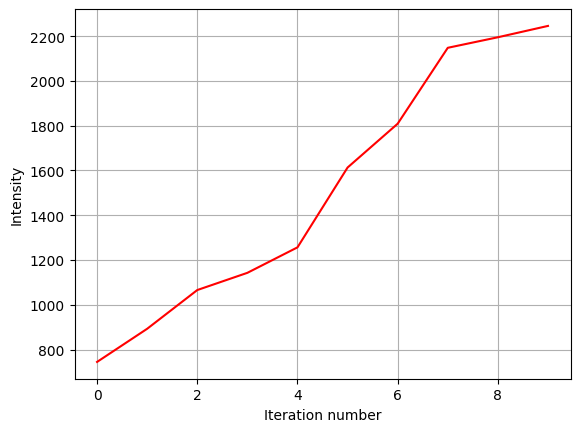

In [9]:
# plot the objective function vs iteration
plt.plot(objective_history, c="red")
plt.xlabel("Iteration number")
plt.ylabel("Intensity")
plt.grid()
plt.show()

To plot the field pattern, we create a 2D [FieldMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) and add it to the final simulation by using the [update_copy](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.components.base.Tidy3dBaseModel.html#tidy3d.components.base.Tidy3dBaseModel.updated_copy) method. Then we run this simulation.

In [10]:
# construct simulation with the final box size
sim_final = make_sim(size_box=param_history[-1])

# add a field monitor for plotting
field_monitor = td.FieldMonitor(
    center=(+L / 2 - buffer, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="fields",
)
sim_final = sim_final.updated_copy(monitors=[field_monitor])

# run the final simulation
data_final = run(sim_final, task_name="quickstart_final")

10:38:15 Eastern Daylight Time Created task 'quickstart_final' with task_id     
                               'fdve-47894fc9-b5e1-45ea-801a-b7af1298406a' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=484200;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=74293;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\taskId]8;;\
                               ]8;id=484200;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\=]8;;\]8;id=348126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\fdve]8;;\]8;id=484200;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\-47894fc9-b5e1-45ea-801a-b7af1298406a']8;;\.

                               Task folder: ]8;id=726947;https://tidy3d.simulation.cloud/folders/639eb096-a602-4b56-a502-cac1f18f9557\'default']8;;\.

Output()

10:38:16 Eastern Daylight Time Maximum FlexCredit cost: 0.025. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

Output()

10:38:31 Eastern Daylight Time status = success

10:38:33 Eastern Daylight Time View simulation result at                        
                               ]8;id=796591;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=118104;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\taskId]8;;\
                               ]8;id=796591;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\=]8;;\]8;id=930827;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\fdve]8;;\]8;id=796591;https://tidy3d.simulation.cloud/workbench?taskId=fdve-47894fc9-b5e1-45ea-801a-b7af1298406a\-47894fc9-b5e1-45ea-801a-b7af1298406a']8;;\.

Output()

10:38:35 Eastern Daylight Time loading simulation from simulation_data.hdf5

Finally, the field distribution is plotted. We denote the source position with a green dot and the measurement position with an orange dot. The orange dot is near a field hotspot as a result of the optimization.

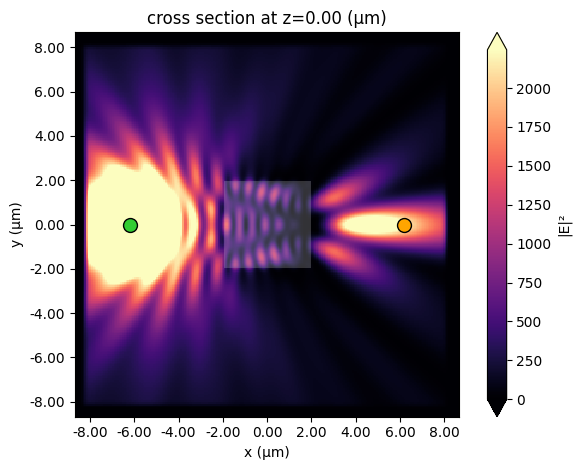

In [11]:
# plot intensity distribution
ax = data_final.plot_field(
    field_monitor_name="fields", field_name="E", val="abs^2", vmax=objective_history[-1]
)

ax.plot(source.center[0], 0, marker="o", mfc="limegreen", mec="black", ms=10)
ax.plot(monitor.center[0], 0, marker="o", mfc="orange", mec="black", ms=10)
plt.show()